# Klasifikasi Arah Pergerakan Harga BTCUSD Menggunakan Machine Learning Multi-Bursa
Notebook ini dirancang untuk memprediksi arah pergerakan harga Bitcoin (BTCUSD) menggunakan data historis terintegrasi dari 7 bursa. Kami menggunakan Polars untuk efisiensi pemrosesan data skala besar, rekayasa fitur stasioner biner (Up vs Down), serta pengujian matriks eksperimen komparatif teroptimasi.

In [1]:
# =========================================================
# 1. PENDAHULUAN & PERSIAPAN LINGKUNGAN
# =========================================================
# Install Polars dan dependency jika belum terpasang di environment Kaggle
!pip install polars pyarrow xgboost scikit-learn matplotlib seaborn kagglehub

import os
import glob
import kagglehub
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Pustaka berhasil diimpor.")

Pustaka berhasil diimpor.


## 1.1. Memuat Dataset Mentah dari Kaggle
Unduh dataset mentah BTCUSD 1 menit secara terpusat dari KaggleHub dan deteksi seluruh file bursa yang tersedia.

Path ke folder dataset: /kaggle/input/datasets/imranbukhari/comprehensive-btcusd-1m-data
Ditemukan 8 file CSV bursa.

=== METADATA STRUKTURAL PER BURSA ===


,Exchange,Rows,Cols
0,Binance,4278671,12
1,BinanceFutures,3203585,12
2,BitMEX,5283245,6
3,Bitfinex,5391322,6
4,Bitstamp,7441823,6
5,Coinbase,5317710,6
6,KuCoin,3908950,7
7,OKX,4075191,9


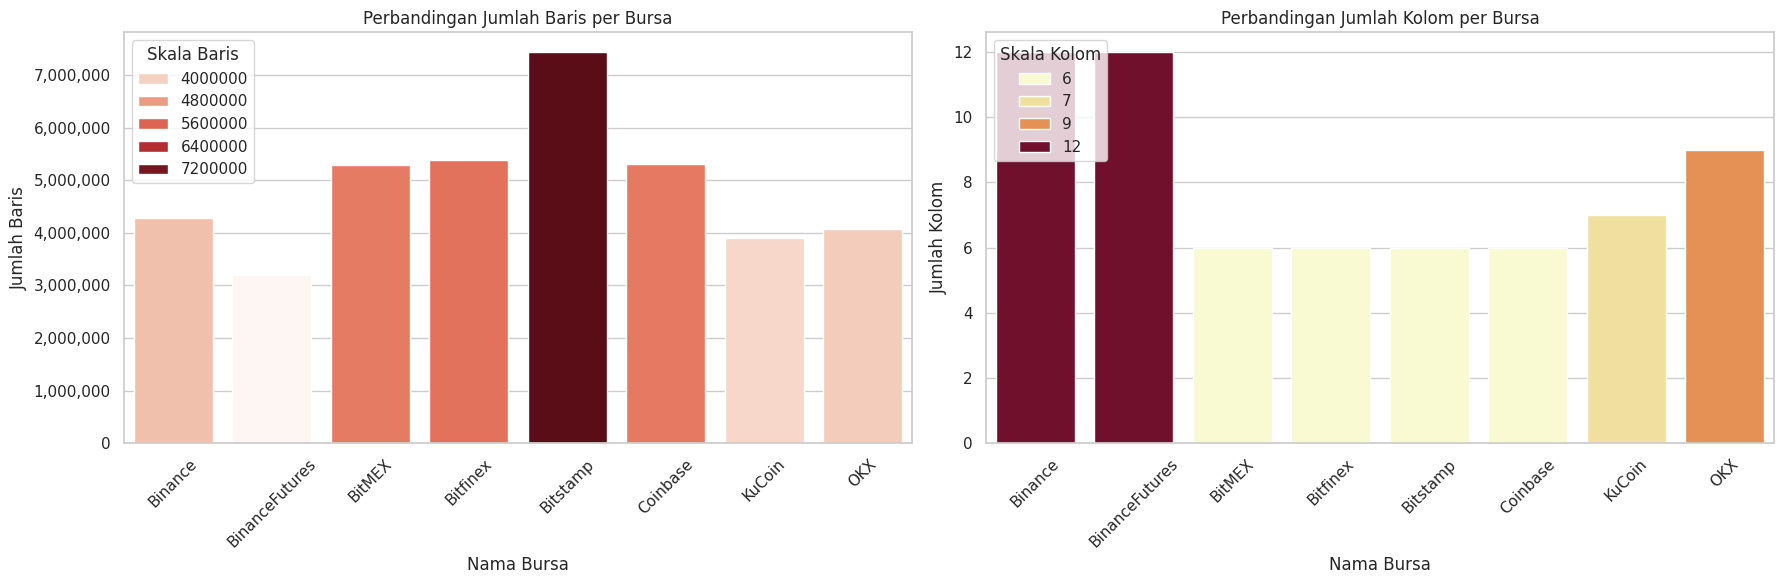

In [2]:
# [Code Cell] Pembaruan Bagian 1.1 - Perbaikan Warning, Kolom, & Gradasi Warna Visualisasi
import os
import glob
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download dataset menggunakan kagglehub
path = kagglehub.dataset_download("imranbukhari/comprehensive-btcusd-1m-data")
print("Path ke folder dataset:", path)

# Mencari seluruh file CSV (kecuali index gabungan jika ada)
file_list = [f for f in glob.glob(os.path.join(path, "BTCUSD_1m_*.csv")) if "Combined_Index" not in f]
print(f"Ditemukan {len(file_list)} file CSV bursa.\n")

# 2. Ekstraksi Metadata untuk Setiap Bursa secara Cepat dan Aman Memori (Lazy)
metadata_records = []
for file_path in sorted(file_list):
    ex_name = os.path.basename(file_path).replace("BTCUSD_1m_", "").replace(".csv", "")
    
    # Gunakan Scan/LazyFrame untuk mendapatkan skema tanpa memuat seluruh file ke RAM
    lf = pl.scan_csv(file_path)
    
    # PERBAIKAN: Menggunakan collect_schema() untuk menghindari PerformanceWarning
    schema = lf.collect_schema()
    
    # Menghitung jumlah baris secara cepat dan efisien
    row_count = lf.select(pl.len()).collect().item()
    col_count = len(schema)
    
    metadata_records.append({
        "Exchange": ex_name,
        "Rows": row_count,
        "Cols": col_count
    })

# Konversi ke Polars DataFrame untuk dicetak secara rapi
df_meta = pl.DataFrame(metadata_records)
df_meta_pd = df_meta.to_pandas()

print("=== METADATA STRUKTURAL PER BURSA ===")
display(df_meta_pd)

# 3. Visualisasi Perbandingan Karakteristik Dataset antar Bursa (Reds Sequential Palette)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Perbandingan Jumlah Baris (Semakin merah berarti baris semakin banyak)
sns.barplot(
    data=df_meta_pd, 
    x="Exchange", 
    y="Rows", 
    hue="Rows", # Hue dipetakan ke nilai kontinu untuk gradasi warna otomatis
    palette="Reds", 
    ax=ax1
)
ax1.set_title("Perbandingan Jumlah Baris per Bursa")
ax1.set_ylabel("Jumlah Baris")
ax1.set_xlabel("Nama Bursa")
ax1.tick_params(axis='x', rotation=45)
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax1.legend(title="Skala Baris", loc="upper left")

# Plot 2: Perbandingan Jumlah Kolom (Semakin oranye/merah berarti kolom semakin banyak)
sns.barplot(
    data=df_meta_pd, 
    x="Exchange", 
    y="Cols", 
    hue="Cols", # Hue dipetakan ke nilai kontinu kolom
    palette="YlOrRd", 
    ax=ax2
)
ax2.set_title("Perbandingan Jumlah Kolom per Bursa")
ax2.set_ylabel("Jumlah Kolom")
ax2.set_xlabel("Nama Bursa")
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title="Skala Kolom", loc="upper left")

plt.tight_layout()
plt.show()

# 2. ANALISIS DATA EKSPLORATIF (EDA)
Tahap eksplorasi data secara global untuk memuat seluruh file bursa, menyatukannya, mendeteksi struktur kolom, nilai kosong, duplikat, dan anomali.

## 2.1. Memuat Seluruh Dataset Bursa
Membaca dan menyeleksi 6 kolom standar (OHLCV) dari seluruh 7 bursa secara konsisten lalu menyatukannya secara vertikal.

In [3]:
# Membaca dan menggabungkan seluruh file CSV bursa sejak awal eksplorasi
dfs = []
kolom_standar = ["Open time", "Open", "High", "Low", "Close", "Volume"]

for file_path in sorted(file_list):
    exchange_name = os.path.basename(file_path).replace("BTCUSD_1m_", "").replace(".csv", "")
    
    # Membaca dataset bursa
    df_temp = pl.read_csv(file_path)
    
    # Menyeleksi hanya kolom standar agar struktur seragam antar bursa
    df_selected = df_temp.select(kolom_standar).with_columns(
        pl.lit(exchange_name).alias("Exchange")
    )
    
    dfs.append(df_selected)
    print(f"Berhasil memuat {exchange_name:<20}: {df_selected.shape[0]:,} baris, {df_selected.shape[1]} kolom")

# Menggabungkan seluruh data secara vertikal (union) setelah strukturnya seragam
df_all_raw = pl.concat(dfs)

print(f"\n=== TOTAL DATASET GABUNGAN SEBELUM AGREGASI ===")
print(f"Ukuran Data Gabungan: {df_all_raw.shape[0]:,} baris, {df_all_raw.shape[1]} kolom\n")

Berhasil memuat Binance             : 4,278,671 baris, 7 kolom
Berhasil memuat BinanceFutures      : 3,203,585 baris, 7 kolom
Berhasil memuat BitMEX              : 5,283,245 baris, 7 kolom
Berhasil memuat Bitfinex            : 5,391,322 baris, 7 kolom
Berhasil memuat Bitstamp            : 7,441,823 baris, 7 kolom
Berhasil memuat Coinbase            : 5,317,710 baris, 7 kolom
Berhasil memuat KuCoin              : 3,908,950 baris, 7 kolom
Berhasil memuat OKX                 : 4,075,191 baris, 7 kolom

=== TOTAL DATASET GABUNGAN SEBELUM AGREGASI ===
Ukuran Data Gabungan: 38,900,497 baris, 7 kolom



## 2.2. Pemahaman Fitur & Statistik Deskriptif Gabungan
Menampilkan cuplikan data terintegrasi serta rangkuman statistik deskriptif dasar dari seluruh parameter numerik di semua bursa.

In [4]:
# Menampilkan beberapa baris pertama data gabungan secara terstruktur
print("Preview 5 Baris Pertama Data Gabungan:")
display(df_all_raw.head(5).to_pandas())

# Deskripsi statistik data gabungan secara keseluruhan
print("\nStatistik Deskriptif Fitur (Seluruh Bursa):")
display(df_all_raw.describe().to_pandas())

Preview 5 Baris Pertama Data Gabungan:


,Open time,Open,High,Low,Close,Volume,Exchange
0,2017-08-17 04:00:00,4261.48,4261.48,4261.48,4261.48,1.775183,Binance
1,2017-08-17 04:01:00,4261.48,4261.48,4261.48,4261.48,0.000000,Binance
2,2017-08-17 04:02:00,4280.56,4280.56,4280.56,4280.56,0.261074,Binance
3,2017-08-17 04:03:00,4261.48,4261.48,4261.48,4261.48,0.012008,Binance
4,2017-08-17 04:04:00,4261.48,4261.48,4261.48,4261.48,0.140796,Binance



Statistik Deskriptif Fitur (Seluruh Bursa):


,statistic,Open time,Open,High,Low,Close,Volume,Exchange
0,count,38900497,3.890050e+07,3.890050e+07,3.890050e+07,3.890050e+07,3.890050e+07,38900497
1,null_count,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0
2,mean,None,2.960548e+04,2.961759e+04,2.959382e+04,2.960689e+04,1.033364e+05,None
3,std,None,3.099714e+04,3.100698e+04,3.098754e+04,3.099810e+04,8.129831e+05,None
4,min,2011-08-18 12:37:00,6.000000e-02,6.000000e-02,6.000000e-02,6.000000e-02,0.000000e+00,Binance
5,25%,None,6.493150e+03,6.495050e+03,6.491100e+03,6.493500e+03,6.409321e-01,None
6,50%,None,1.877100e+04,1.878043e+04,1.876100e+04,1.877222e+04,4.911656e+00,None
7,75%,None,4.518070e+04,4.520564e+04,4.515600e+04,4.518390e+04,3.768737e+01,None
8,max,2025-10-11 11:02:00,1.262020e+05,1.262960e+05,1.261720e+05,1.262720e+05,1.553707e+08,OKX


## 2.3. Analisis Kualitas Data Gabungan (Struktur, Nulls, Duplikat, dan Anomali)
Menghitung jumlah data kosong (null), memeriksa baris duplikat antar-bursa, serta mendeteksi harga anomali bernilai nol di seluruh bursa secara serentak.

In [5]:
# Memeriksa data hilang (Null) pada seluruh dataset gabungan
null_report = df_all_raw.select([
    pl.col(c).null_count().alias(c) for c in df_all_raw.columns
])
print("=== JUMLAH NILAI NULL GLOBAL PER KOLOM ===")
display(null_report.to_pandas())

# Memeriksa duplikat baris (berdasarkan kombinasi timestamp dan bursa untuk menghindari tabrakan antar bursa)
if "Open time" in df_all_raw.columns:
    dup_count = df_all_raw.shape[0] - df_all_raw.unique(subset=["Open time", "Exchange"]).shape[0]
    print(f"Jumlah baris duplikat berdasarkan kombinasi 'Open time' & 'Exchange': {dup_count:,}")
else:
    print("Kolom 'Open time' tidak ditemukan.")

# Deteksi anomali harga Close = 0 pada seluruh bursa
if "Close" in df_all_raw.columns:
    zero_close_count = df_all_raw.filter(pl.col("Close") == 0).shape[0]
    print(f"Jumlah anomali harga Close bernilai 0 di seluruh bursa: {zero_close_count}")

=== JUMLAH NILAI NULL GLOBAL PER KOLOM ===


,Open time,Open,High,Low,Close,Volume,Exchange
0,0,0,0,0,0,0,0


Jumlah baris duplikat berdasarkan kombinasi 'Open time' & 'Exchange': 0
Jumlah anomali harga Close bernilai 0 di seluruh bursa: 0


## 2.4. Analisis Korelasi Fitur Gabungan
Visualisasi korelasi linier dasar antar-fitur harga dan volume mentah yang tergabung dari seluruh bursa.

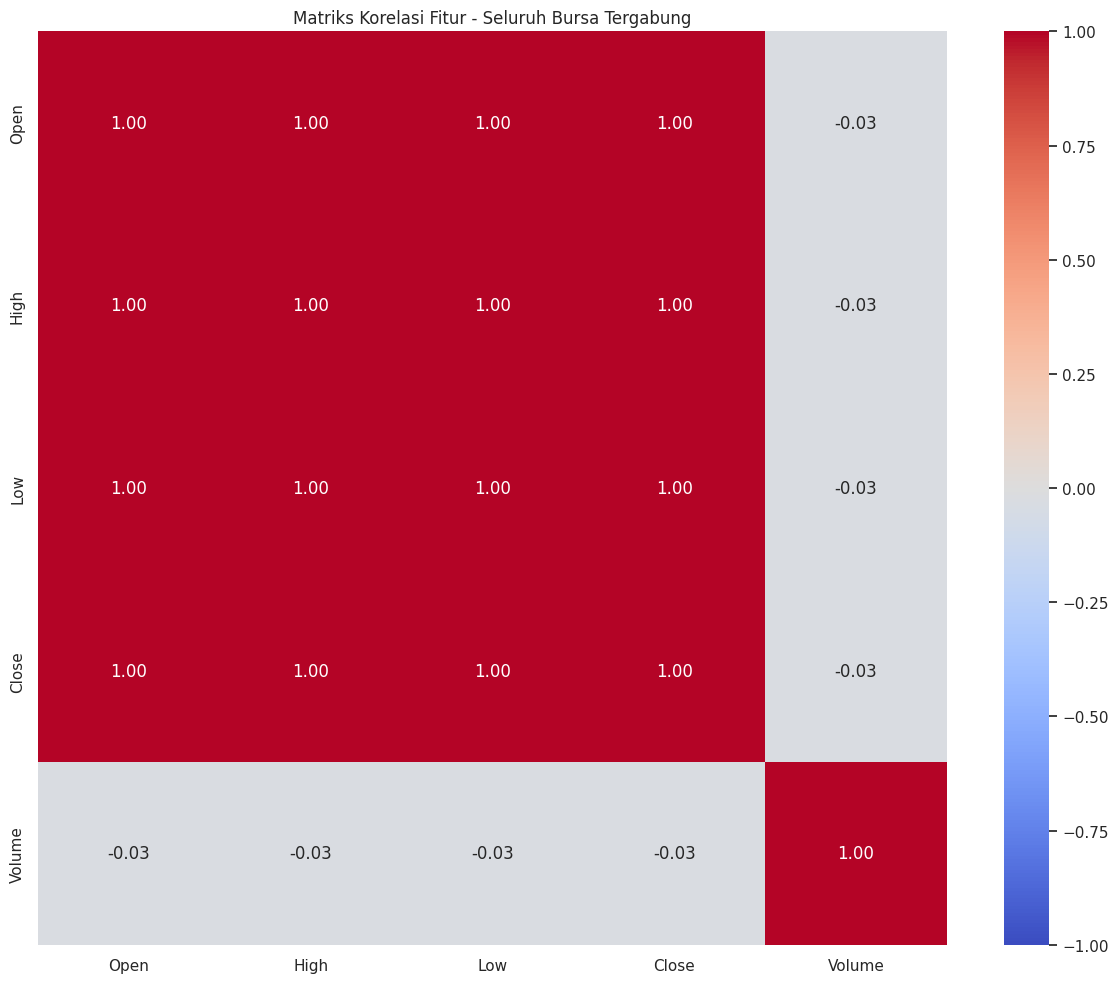

In [6]:
# Mengambil kolom ber-tipe data numerik saja untuk matriks korelasi global
numeric_cols = [c for c, dtype in df_all_raw.schema.items() if dtype in [pl.Float64, pl.Int64]]
df_numeric = df_all_raw.select(numeric_cols)

# Hitung matriks korelasi dari seluruh data bursa tergabung
corr_matrix = df_numeric.to_pandas().corr()

# Tampilkan visualisasi matriks korelasi gabungan bursa
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriks Korelasi Fitur - Seluruh Bursa Tergabung")
plt.tight_layout()
plt.show()

# 3. REKAYASA FITUR & STRATEGI PELABELAN KLASIFIKASI
Membangun dataset runtun waktu multi-skala, mentransformasikan harga mentah menjadi fitur stasioner, serta membuat label target biner.

## 3.1. Agregasi Multi-Skala Waktu (Hour, Day, Week, Month, 1m, 15m, 30m, Raw)
Melakukan penggabungan data seluruh bursa secara dinamis ke dalam berbagai skala waktu serta mempertahankan dataset mentah asli tanpa agregasi (Raw).

In [7]:
# Membaca seluruh file CSV dan menyatukannya ke dalam satu DataFrame gabungan menggunakan Polars
lazy_dfs = []
cols_to_keep = ["Open time", "Open", "High", "Low", "Close", "Volume"]

for file_path in file_list:
    ex_name = os.path.basename(file_path).replace("BTCUSD_1m_", "").replace(".csv", "")
    # Gunakan Scan CSV untuk efisiensi memori (LazyFrame)
    lf = pl.scan_csv(file_path).select(cols_to_keep).with_columns([
        pl.col("Open time").str.to_datetime(),
        pl.lit(ex_name).alias("Exchange")
    ])
    lazy_dfs.append(lf)

# Menggabungkan seluruh data bursa secara vertikal
df_all_raw = pl.concat(lazy_dfs).collect()

# === PENGAMAN GLOBAL: Mengonversi kolom "Open time" ke Datetime jika masih bertipe String ===
if df_all_raw["Open time"].dtype == pl.String:
    print("Mengonversi kolom 'Open time' ke Datetime secara global...")
    df_all_raw = df_all_raw.with_columns(
        pl.col("Open time").str.to_datetime()
    )

print(f"Total baris seluruh bursa terkumpul: {df_all_raw.shape[0]:,}")

# Fungsi agregasi multi-skala waktu
def aggregate_data(df, interval):
    # Menyeleraskan ke UTC dan melakukan group_by dinamis
    df_sorted = df.sort("Open time")
    
    df_agg = df_sorted.group_by_dynamic(
        "Open time", 
        every=interval, 
        closed="left"
    ).agg([
        pl.col("Open").first().alias("Open"),
        pl.col("High").max().alias("High"),
        pl.col("Low").min().alias("Low"),
        pl.col("Close").last().alias("Close"),
        pl.col("Volume").sum().alias("Volume")
    ]).drop_nulls()
    
    return df_agg

# Menentukan parameter agregasi skala waktu
agg_resolutions = {
    "1m": "1 Minute",
    "15m": "15 Minute",
    "30m": "30 Minute",
    "1h": "Hour", 
    "1d": "Day", 
    "1w": "Week", 
    "1mo": "Month"
}
agg_data_dict = {}

# Melakukan proses agregasi runtun waktu secara dinamis
for res, name in agg_resolutions.items():
    agg_data_dict[name] = aggregate_data(df_all_raw, res)
    print(f"Ukuran data setelah agregasi ({name:<10}): {agg_data_dict[name].shape[0]:,} baris")

# Menyimpan dataset asli gabungan seluruh bursa TANPA AGREGASI (Seluruh 38.9 Juta Baris)
agg_data_dict["Raw (No Agg)"] = df_all_raw
print(f"Ukuran data tanpa agregasi (Raw)     : {agg_data_dict['Raw (No Agg)'].shape[0]:,} baris")

Total baris seluruh bursa terkumpul: 38,900,497
Ukuran data setelah agregasi (1 Minute  ): 7,441,826 baris
Ukuran data setelah agregasi (15 Minute ): 496,123 baris
Ukuran data setelah agregasi (30 Minute ): 248,062 baris
Ukuran data setelah agregasi (Hour      ): 124,032 baris
Ukuran data setelah agregasi (Day       ): 5,169 baris
Ukuran data setelah agregasi (Week      ): 739 baris
Ukuran data setelah agregasi (Month     ): 171 baris
Ukuran data tanpa agregasi (Raw)     : 38,900,497 baris


## 3.2. Pembuatan Fitur Teknikal & Pelabelan Biner
Membangun fitur stasioner stabil bebas nilai tak terhingga (inf), menghilangkan multikolinearitas harga mentah, serta melabeli target arah biner (Up/Down).

In [8]:
def build_features_and_labels_binary(df_agg):
    df_feat = df_agg.sort("Open time")
    
    # 1. Fitur stasioner dasar (Log Return, Volume Change, SMA Ratio) dengan stabilisasi matematika
    df_feat = df_feat.with_columns([
        ((pl.col("Close") + 1e-5) / (pl.col("Close").shift(1) + 1e-5)).log().alias("Log_Return"),
        ((pl.col("Volume") + 1e-5) / (pl.col("Volume").shift(1).fill_null(strategy="zero") + 1e-5)).log().alias("Volume_Change"),
        (pl.col("Close").rolling_mean(window_size=5) / pl.col("Close").rolling_mean(window_size=15)).alias("SMA_Ratio")
    ])
    
    # 2. Volatilitas Historis (Window 10)
    log_ret_temp = ((pl.col("Close") + 1e-5) / (pl.col("Close").shift(1) + 1e-5)).log()
    df_feat = df_feat.with_columns(
        log_ret_temp.rolling_std(window_size=10).alias("Volatility_10")
    )
    
    # 3. RSI Sederhana (Window 14)
    diff = pl.col("Close").diff()
    gain = pl.when(diff > 0).then(diff).otherwise(0.0)
    loss = pl.when(diff < 0).then(-diff).otherwise(0.0)
    avg_gain = gain.rolling_mean(window_size=14)
    avg_loss = loss.rolling_mean(window_size=14)
    rs = avg_gain / (avg_loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    df_feat = df_feat.with_columns(rsi.alias("RSI_14"))
    
    # 4. Lag Fitur stasioner
    df_feat = df_feat.with_columns([
        pl.col("Log_Return").shift(1).alias("Lag_Log_Return_1"),
        pl.col("Volume_Change").shift(1).alias("Lag_Volume_Change_1")
    ])
    
    # 5. Pelabelan Biner (Threshold = 0.0)
    next_return = (pl.col("Close").shift(-1) - pl.col("Close")) / pl.col("Close")
    df_feat = df_feat.with_columns(
        pl.when(next_return > 0.0).then(1) # Up
        .otherwise(0)                      # Down / No Change
        .alias("Target")
    )
    
    # Pengaman Inf & Null secara eksplisit
    df_feat = df_feat.drop_nulls()
    df_feat = df_feat.with_columns([
        pl.col(c).replace({float("inf"): None, float("-inf"): None})
        for c in df_feat.columns if df_feat[c].dtype == pl.Float64
    ]).drop_nulls()
    
    return df_feat

# Menjalankan pemrosesan biner pada skala per jam (Hour)
df_model_ready = build_features_and_labels_binary(agg_data_dict["Hour"])
print(f"Dataset biner berhasil dibangun. Jumlah data: {df_model_ready.shape[0]:,} baris.")

Dataset biner berhasil dibangun. Jumlah data: 124,018 baris.


## 3.3. Cek Korelasi Fitur Baru
Memvalidasi skor korelasi setiap fitur stasioner yang baru dibuat terhadap variabel Target.

=== NILAI KORELASI FITUR BARU TERHADAP TARGET ===
Volume_Change        : +0.005138
Lag_Volume_Change_1  : +0.003442
RSI_14               : -0.001090
SMA_Ratio            : -0.011871
Volatility_10        : -0.019864
Lag_Log_Return_1     : -0.020246
Log_Return           : -0.048060


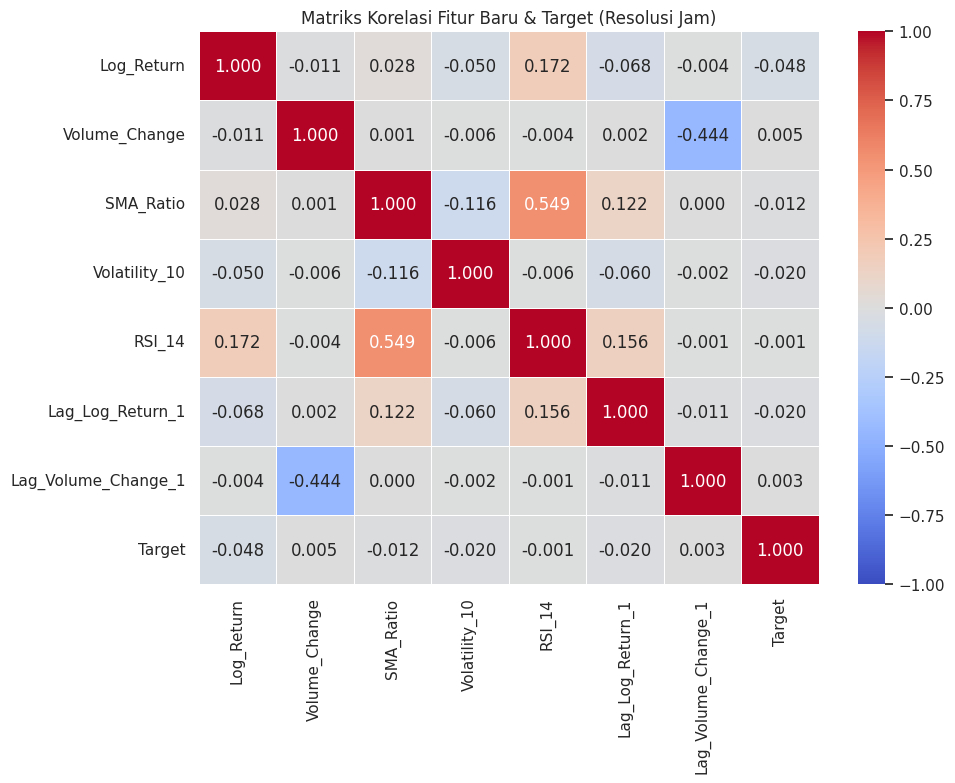

In [9]:
# 1. Memilih kolom hasil feature engineering untuk dianalisis korelasinya
cols_to_correlate = [
    "Log_Return", "Volume_Change", "SMA_Ratio", 
    "Volatility_10", "RSI_14", 
    "Lag_Log_Return_1", "Lag_Volume_Change_1", "Target"
]

# Mengonversi subset Polars ke Pandas untuk perhitungan korelasi dan visualisasi
df_corr_prep = df_model_ready.select(cols_to_correlate).to_pandas()
correlation_matrix = df_corr_prep.corr()

# 2. Menampilkan nilai korelasi spesifik setiap fitur terhadap Target secara berurutan
print("=== NILAI KORELASI FITUR BARU TERHADAP TARGET ===")
target_corr = correlation_matrix["Target"].sort_values(ascending=False)
for feature, score in target_corr.items():
    if feature != "Target":
        print(f"{feature:<20} : {score:+.6f}")
print("============================================")

# 3. Visualisasi Heatmap Korelasi Hasil Feature Engineering Baru
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".3f", 
    vmin=-1, 
    vmax=1,
    linewidths=0.5
)
plt.title("Matriks Korelasi Fitur Baru & Target (Resolusi Jam)")
plt.tight_layout()
plt.show()

# 4. PERSIAPAN DATA UNTUK MODELING
Tahap pemisahan fitur input/output, pembagian porsi latih dan uji berbasis urutan waktu, normalisasi penskalaan fitur, dan analisis proporsi kelas.

## 4.1. Persiapan Dataset Mentah (No FE) vs Rekayasa Fitur (FE)
Mempersiapkan dataset fitur mentah (No FE) dan fitur rekayasa stasioner (FE) lalu membagi porsi latih/uji (80:20) berdasarkan urutan waktu.

In [10]:
# 1. Menentukan kolom fitur mentah (No FE) dan hasil rekayasa (FE) yang valid
feature_cols_raw = ["Open", "High", "Low", "Close", "Volume"]
feature_cols_fe = [
    "Log_Return", "Volume_Change", "SMA_Ratio", 
    "Volatility_10", "RSI_14", 
    "Lag_Log_Return_1", "Lag_Volume_Change_1"
]
target_col = "Target"

# 2. Pembagian index runtun waktu (80% Train, 20% Test)
split_idx = int(len(df_model_ready) * 0.8)

# Target label biner (sama untuk seluruh pengujian)
y_all = df_model_ready.select(target_col).to_numpy().ravel()
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

# Fitur Mentah (No FE)
X_raw = df_model_ready.select(feature_cols_raw).to_numpy()
X_raw_train, X_raw_test = X_raw[:split_idx], X_raw[split_idx:]

# Fitur Hasil Rekayasa (FE)
X_fe = df_model_ready.select(feature_cols_fe).to_numpy()
X_fe_train, X_fe_test = X_fe[:split_idx], X_fe[split_idx:]

# Menentukan variabel latih acak untuk keperluan plot visualisasi penskalaan
X_train, X_test = X_fe_train, X_fe_test

print(f"Data Latih (Train) : {X_raw_train.shape[0]:,} baris")
print(f"Data Uji (Test)   : {X_raw_test.shape[0]:,} baris")

Data Latih (Train) : 99,214 baris
Data Uji (Test)   : 24,804 baris


## 4.2. Penskalaan Fitur (Feature Scaling)
Melakukan proses penskalaan StandardScaler dan menampilkan visualisasi perbandingan distribusi fitur sebelum/sesudah dinormalisasi.

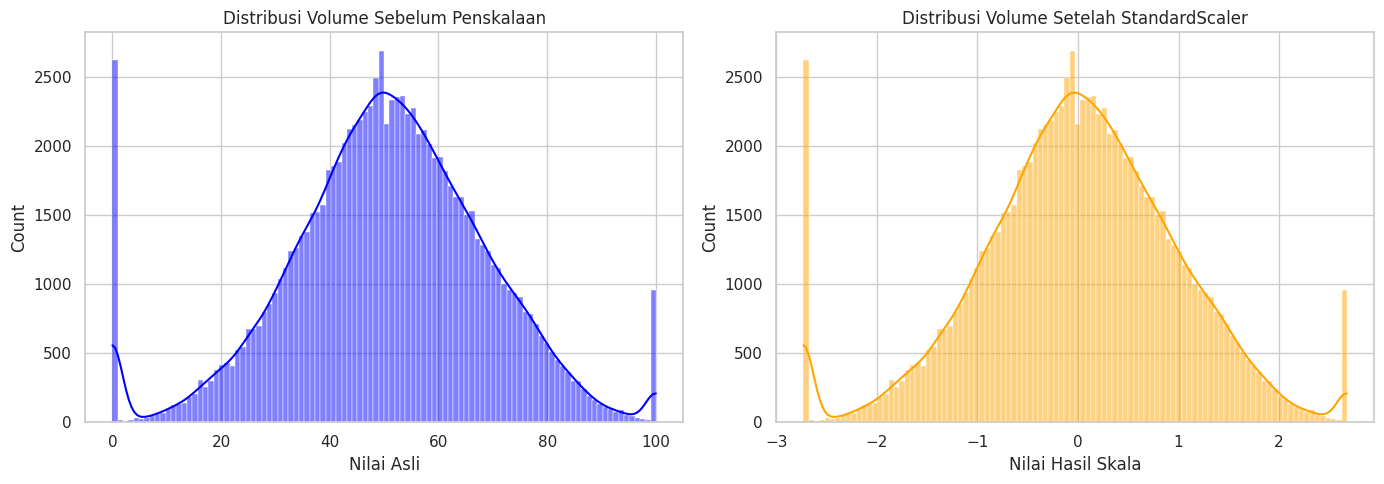

In [11]:
scaler = StandardScaler()

# Melakukan fit pada data latih saja, lalu transform ke data latih & uji
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Visualisasi efek penskalaan fitur (contoh kolom Volume di indeks ke-4)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(X_train[:, 4], kde=True, ax=ax1, color="blue")
ax1.set_title("Distribusi Volume Sebelum Penskalaan")
ax1.set_xlabel("Nilai Asli")

sns.histplot(X_train_scaled[:, 4], kde=True, ax=ax2, color="orange")
ax2.set_title("Distribusi Volume Setelah StandardScaler")
ax2.set_xlabel("Nilai Hasil Skala")

plt.tight_layout()
plt.show()

## 4.3. Analisis Ketidakseimbangan Data (Imbalanced Data Analysis)
Memantau persentase sebaran kelas target biner (Up vs Down) baik secara keseluruhan maupun dalam porsi data pelatihan.

In [12]:
# Hitung distribusi kelas menggunakan Polars group_by
class_dist = df_model_ready.group_by("Target").agg(
    pl.len().alias("Counts")
).with_columns(
    (pl.col("Counts") / pl.col("Counts").sum() * 100).alias("Percentage")
).sort("Target")

print("=== DISTRIBUSI KELAS TARGET (KESELURUHAN) ===")
display(class_dist.to_pandas())

# Distribusi kelas spesifik di set pelatihan
unique_tr, counts_tr = np.unique(y_train, return_counts=True)
pct_tr = counts_tr / counts_tr.sum() * 100
print("\n=== DISTRIBUSI KELAS TARGET (SET LATIH/TRAIN) ===")
for u, c, p in zip(unique_tr, counts_tr, pct_tr):
    print(f"Kelas {u}: {c:,} baris ({p:.2f}%)")

=== DISTRIBUSI KELAS TARGET (KESELURUHAN) ===


,Target,Counts,Percentage
0,0,64613,52.099695
1,1,59405,47.900305



=== DISTRIBUSI KELAS TARGET (SET LATIH/TRAIN) ===
Kelas 0: 52,434 baris (52.85%)
Kelas 1: 46,780 baris (47.15%)


# 5. PENGEMBANGAN MODEL & EVALUASI
Membangun arsitektur pipeline, merancang parameter Grid Search, melatih model, dan mengeksekusi matriks komparatif eksperimen.

## 5.1. Inisialisasi Fungsi Eksekutor Eksperimen & Parameter Grid
Mempersiapkan pipeline pengujian terintegrasi, parameter grid pencarian, serta melatih Grid Search yang disimulasikan menggunakan skema TimeSeriesSplit.

In [13]:
# Inisialisasi skema validasi silang runtun waktu (5 lipatan)
tscv = TimeSeriesSplit(n_splits=5)

# 1. Pipeline Random Forest menggunakan balanced_subsample untuk bootstrap penyeimbang
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(
        n_estimators=100, 
        class_weight="balanced_subsample", 
        random_state=42, 
        n_jobs=-1
    ))
])

# 2. Pipeline XGBoost standar
xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", XGBClassifier(
        n_estimators=100, 
        random_state=42, 
        eval_metric="mlogloss", 
        n_jobs=-1
    ))
])

# Menentukan parameter grid pencarian untuk tuning ringan agar efisien di Kaggle
rf_param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [5, 10]
}

xgb_param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [4, 6],
    "classifier__learning_rate": [0.05, 0.1]
}

# Fungsi otomatis untuk menjalankan satu konfigurasi eksperimen
def run_classification_experiment(model_name, scenario_name, pipeline, param_grid, X_tr, y_tr, X_te, y_te, use_tuning=False):
    if use_tuning:
        # Menjalankan Grid Search secara aman di dalam lipatan runtun waktu
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=tscv,
            scoring="accuracy",
            n_jobs=-1
        )
        grid_search.fit(X_tr, y_tr)
        best_model = grid_search.best_estimator_
        best_params = str(grid_search.best_params_)
        
        # Cetak parameter optimal yang ditemukan
        print(f"[{model_name} | {scenario_name}] Parameter Optimal: {grid_search.best_params_}")
    else:
        # Melatih langsung model default tanpa tuning
        best_model = pipeline
        best_model.fit(X_tr, y_tr)
        best_params = "Default"
        
    # Evaluasi Prediksi
    y_pred = best_model.predict(X_te)
    y_proba = best_model.predict_proba(X_te)[:, 1] # Probabilitas kelas positif biner
    
    # Kalkulasi Metrik Evaluasi
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_te, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_te, y_pred, average="weighted", zero_division=0)
    auc = roc_auc_score(y_te, y_proba)
    
    metrics = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "AUC-ROC": auc,
        "Params": best_params
    }
    
    return metrics, best_model

print("Pipeline evaluasi dengan TimeSeriesSplit dan balanced_subsample berhasil disiapkan.")

Pipeline evaluasi dengan TimeSeriesSplit dan balanced_subsample berhasil disiapkan.


## 5.2. Eksekusi Matriks Eksperimen Komparatif
Meluncurkan loop simulasi eksekusi pengujian dari 4 skenario kombinasi yang berbeda (No FE, FE, No Tuning, Tuning) untuk Random Forest dan XGBoost.

In [14]:
results_list = []
trained_models = {}  # Koleksi untuk menyimpan model terlatih secara instan

# Konfigurasi Skenario Matriks
scenarios = [
    {"Name": "No FE + No Tuning", "X_train": X_raw_train, "X_test": X_raw_test, "Tuning": False},
    {"Name": "FE + No Tuning",    "X_train": X_fe_train,  "X_test": X_fe_test,  "Tuning": False},
    {"Name": "No FE + Tuning",    "X_train": X_raw_train, "X_test": X_raw_test, "Tuning": True},
    {"Name": "FE + Tuning",       "X_train": X_fe_train,  "X_test": X_fe_test,  "Tuning": True}
]

# 1. Menjalankan Eksperimen untuk Random Forest
print("=== MENGEKSEKUSI MATRIKS EKSPERIMEN: RANDOM FOREST ===")
for sc in scenarios:
    res, model_obj = run_classification_experiment(
        model_name="Random Forest",
        scenario_name=sc["Name"],
        pipeline=rf_pipeline,
        param_grid=rf_param_grid,
        X_tr=sc["X_train"],
        y_tr=y_train,
        X_te=sc["X_test"],
        y_te=y_test,
        use_tuning=sc["Tuning"]
    )
    results_list.append({"Model": "Random Forest", "Scenario": sc["Name"], **res})
    trained_models[f"Random Forest_{sc['Name']}"] = model_obj

# 2. Menjalankan Eksperimen untuk XGBoost
print("\n=== MENGEKSEKUSI MATRIKS EKSPERIMEN: XGBOOST ===")
for sc in scenarios:
    res, model_obj = run_classification_experiment(
        model_name="XGBoost",
        scenario_name=sc["Name"],
        pipeline=xgb_pipeline,
        param_grid=xgb_param_grid,
        X_tr=sc["X_train"],
        y_tr=y_train,
        X_te=sc["X_test"],
        y_te=y_test,
        use_tuning=sc["Tuning"]
    )
    results_list.append({"Model": "XGBoost", "Scenario": sc["Name"], **res})
    trained_models[f"XGBoost_{sc['Name']}"] = model_obj

print("\nMatriks eksperimen selesai dieksekusi.")

=== MENGEKSEKUSI MATRIKS EKSPERIMEN: RANDOM FOREST ===
[Random Forest | No FE + Tuning] Parameter Optimal: {'classifier__max_depth': 5, 'classifier__n_estimators': 100}
[Random Forest | FE + Tuning] Parameter Optimal: {'classifier__max_depth': 5, 'classifier__n_estimators': 50}

=== MENGEKSEKUSI MATRIKS EKSPERIMEN: XGBOOST ===
[XGBoost | No FE + Tuning] Parameter Optimal: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 100}
[XGBoost | FE + Tuning] Parameter Optimal: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 100}

Matriks eksperimen selesai dieksekusi.


## 5.3. Visualisasi Hasil Evaluasi Klasifikasi Biner
Menyediakan modul visualisasi plot matriks kebingungan (confusion matrix), laporan klasifikasi, dan visualisasi plot kurva ROC-AUC untuk hasil evaluasi model.

In [15]:
# Fungsi visualisasi confusion matrix
def plot_evaluation_results(y_true, y_pred, model_name):
    # Disesuaikan menjadi target_names biner
    print(f"\n================ LAPORAN KLASIFIKASI: {model_name} ================")
    print(classification_report(y_true, y_pred, target_names=["Down (0)", "Up (1)"]))
    
    # Matriks Kebingungan
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Down", "Up"],
                yticklabels=["Down", "Up"])
    plt.ylabel("Aktual")
    plt.xlabel("Prediksi")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.tight_layout()
    plt.show()

# Fungsi visualisasi kurva ROC-AUC
def plot_rocauc(y_test, y_probs):
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.50)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)

# 6. PERBANDINGAN MODEL & ANALISIS DIAGNOSTIK
Menghitung rangkuman performa perbandingan seluruh skenario komparatif dan menentukan model terbaik secara terprogram.

## 6.1. Perbandingan Hasil Akhir Eksperimen Komparatif
Merangkum metrik dari 8 skenario pengujian komparatif ke dalam struktur tabel Polars DataFrame yang terurut berdasarkan akurasi tertinggi.

In [16]:
# Membuat DataFrame ringkasan dari list hasil eksperimen
df_comparative_summary = pl.DataFrame(results_list)

# Mengurutkan berdasarkan performa akurasi tertinggi untuk kemudahan analisis
df_comparative_summary = df_comparative_summary.sort("Accuracy", descending=True)

print("=== RINGKASAN MATRIKS EKSPERIMEN KOMPARATIF ===")
display(df_comparative_summary.to_pandas())

=== RINGKASAN MATRIKS EKSPERIMEN KOMPARATIF ===


,Model,Scenario,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Params
0,XGBoost,FE + Tuning,0.537010,0.537047,0.537010,0.537026,0.549296,"{'classifier__learning_rate': 0.1, 'classifier..."
1,Random Forest,FE + Tuning,0.531850,0.533646,0.531850,0.511859,0.548943,"{'classifier__max_depth': 5, 'classifier__n_es..."
2,XGBoost,FE + No Tuning,0.530560,0.530254,0.530560,0.530167,0.539726,Default
3,Random Forest,FE + No Tuning,0.521609,0.521868,0.521609,0.521636,0.528388,Default
4,Random Forest,No FE + Tuning,0.503870,0.502983,0.503870,0.502100,0.502134,"{'classifier__max_depth': 5, 'classifier__n_es..."
5,XGBoost,No FE + No Tuning,0.503507,0.501574,0.503507,0.496181,0.498900,Default
6,Random Forest,No FE + No Tuning,0.501532,0.506865,0.501532,0.477321,0.506974,Default
7,XGBoost,No FE + Tuning,0.497097,0.497213,0.497097,0.497135,0.498146,"{'classifier__learning_rate': 0.1, 'classifier..."


## 6.2. Seleksi & Evaluasi Komprehensif Model Terbaik
Memilih objek model terbaik secara dinamis dari tabel ringkasan, mencetak detail parameter optimalnya, dan menampilkan performa evaluasi penuh.

MODEL TERBAIK YANG TERPILIH : XGBoost
SKENARIO TERBAIK            : FE + Tuning
AKURASI DATA UJI            : 0.537010
PARAMETER OPTIMAL           : {'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 100}


================ LAPORAN KLASIFIKASI: XGBoost (FE + Tuning) ================
              precision    recall  f1-score   support

    Down (0)       0.53      0.53      0.53     12179
      Up (1)       0.55      0.54      0.54     12625

    accuracy                           0.54     24804
   macro avg       0.54      0.54      0.54     24804
weighted avg       0.54      0.54      0.54     24804



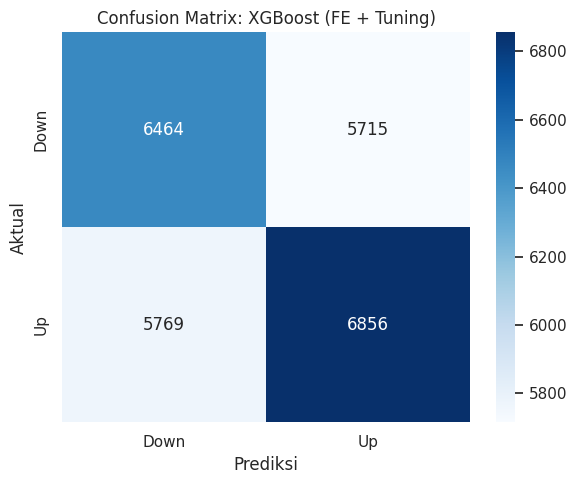

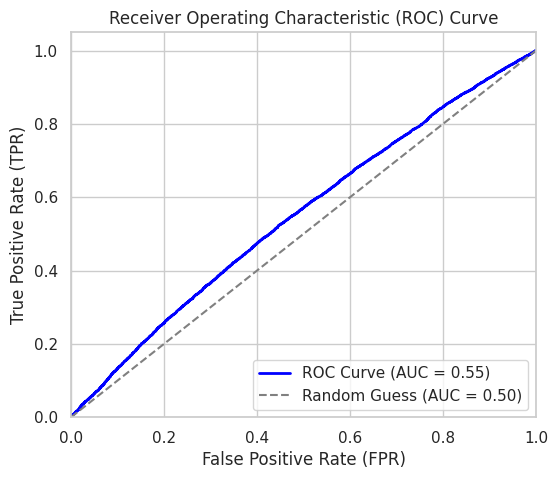

In [17]:
# Konversi ringkasan hasil ke Pandas DataFrame untuk kemudahan indeksasi
df_res_pandas = df_comparative_summary.to_pandas()

# Menemukan baris dengan akurasi tertinggi
best_idx = df_res_pandas["Accuracy"].idxmax()
best_row = df_res_pandas.loc[best_idx]

best_model_name = best_row["Model"]
best_scenario = best_row["Scenario"]
best_accuracy = best_row["Accuracy"]

print("=====================================================================")
print(f"MODEL TERBAIK YANG TERPILIH : {best_model_name}")
print(f"SKENARIO TERBAIK            : {best_scenario}")
print(f"AKURASI DATA UJI            : {best_accuracy:.6f}")
print(f"PARAMETER OPTIMAL           : {best_row['Params']}")
print("=====================================================================\n")

# Mengambil objek model terbaik dari penyimpanan koleksi
best_model_key = f"{best_model_name}_{best_scenario}"
best_model_obj = trained_models[best_model_key]

# Menentukan dataset uji yang sesuai (No FE vs FE) berdasarkan skenario terbaik
X_test_best = X_fe_test if "FE" in best_scenario else X_raw_test

# Membuat prediksi akhir
y_pred_best = best_model_obj.predict(X_test_best)
y_proba_best = best_model_obj.predict_proba(X_test_best)[:, 1]

# Menampilkan Laporan Klasifikasi & Confusion Matrix akhir
plot_evaluation_results(y_test, y_pred_best, f"{best_model_name} ({best_scenario})")

# Menampilkan Kurva ROC-AUC
plot_rocauc(y_test, y_proba_best)